In [2]:
import os
import numpy as np
import polars as pl
from torch.utils.data import Dataset
from torchvision.io import decode_image
import matplotlib.pyplot as plt
import torch

In [3]:

pl.Config.set_tbl_rows(-1)
pl.Config.set_tbl_width_chars(-1)
pl.Config.set_tbl_cols(-1)
pl.Config.set_fmt_table_cell_list_len(-1)
pl.Config.set_fmt_str_lengths(1000)


polars.config.Config

In [4]:
root_dir = os.path.expanduser('~/scr/cell_crops/')
metadata_path = os.path.join(root_dir, 'metadata.csv')

In [5]:
metadata = pl.read_csv(metadata_path)
first_entry = metadata[0]

In [6]:
metadata.__len__()

1138378

In [7]:
dict_meta = metadata.rows(named=True)

In [8]:
len(dict_meta)

1138378

In [9]:
dict_meta[0]

{'': 0,
 'cell_id': 1.0,
 'x1': 293.0,
 'y1': 138.0,
 'x2': 731.0,
 'y2': 886.0,
 'if_plate_id': 1,
 'position': 'A1',
 'sample': 1,
 'atlas_name': 'U2OS',
 'antibody': 'HPA000992',
 'ensembl_ids': 'ENSG00000066455',
 'gene_names': 'GOLGA5',
 'locations': 'Golgi apparatus'}

In [10]:
first_entry

,cell_id,x1,y1,x2,y2,if_plate_id,position,sample,atlas_name,antibody,ensembl_ids,gene_names,locations
i64,f64,f64,f64,f64,f64,i64,str,i64,str,str,str,str,str
0,1.0,293.0,138.0,731.0,886.0,1,"""A1""",1,"""U2OS""","""HPA000992""","""ENSG00000066455""","""GOLGA5""","""Golgi apparatus"""


In [11]:
plate = str(first_entry['if_plate_id'].item())
position = str(first_entry['position'].item())
sample = str(first_entry['sample'].item())
cell_id = sample = str(int(first_entry['cell_id'].item()))
image = os.path.join(root_dir, plate, f"{plate}_{position}_{sample}_{cell_id}_cell_image.png")
pask = os.path.join(root_dir, plate, f"{plate}_{position}_{sample}_{cell_id}_cell_mask.png")

In [12]:
metadata.head()

,cell_id,x1,y1,x2,y2,if_plate_id,position,sample,atlas_name,antibody,ensembl_ids,gene_names,locations
i64,f64,f64,f64,f64,f64,i64,str,i64,str,str,str,str,str
0,1.0,293.0,138.0,731.0,886.0,1,"""A1""",1,"""U2OS""","""HPA000992""","""ENSG00000066455""","""GOLGA5""","""Golgi apparatus"""
1,2.0,-12.0,305.0,1036.0,719.0,1,"""A1""",1,"""U2OS""","""HPA000992""","""ENSG00000066455""","""GOLGA5""","""Golgi apparatus"""
2,3.0,226.0,281.0,798.0,743.0,1,"""A1""",1,"""U2OS""","""HPA000992""","""ENSG00000066455""","""GOLGA5""","""Golgi apparatus"""
3,4.0,182.0,214.0,842.0,810.0,1,"""A1""",1,"""U2OS""","""HPA000992""","""ENSG00000066455""","""GOLGA5""","""Golgi apparatus"""
4,5.0,348.0,287.0,676.0,737.0,1,"""A1""",1,"""U2OS""","""HPA000992""","""ENSG00000066455""","""GOLGA5""","""Golgi apparatus"""


In [13]:
class UnZippedImageArchive(Dataset):
    """Basic unzipped image arch. This will no longer be used. 
       Remove when unzipped support is added to the IterableImageArchive
    """
    def __init__(self, root_dir: str= '~/scr/cell_crops/') -> None:
        super().__init__()
        self.root_dir = os.path.expanduser(root_dir)
        self.metadata_path = os.path.join(self.root_dir, 'metadata.csv')
        self.metadata = pl.read_csv(self.metadata_path).rows(named=True)        
        
    def __len__(self):
        return len(self.metadata)
    
    def __getitem__(self, idx):
        # microtubule fluorescence,  Blue (B) channel
        # endoplasmic reticulum,  Green (G) channel
        # DNA, Red (R) channel
        # Protein of interest, Alpha (A) channel.
        # https://virtualcellmodels.cziscience.com/dataset/01933229-3c87-7818-be80-d7e5578bb0b7
        row = self.metadata[idx]
        plate = str(row['if_plate_id'])
        position = row['position']
        sample = str(row['sample'])
        cell_id = str(int(row['cell_id']))
        image = os.path.join(root_dir, plate, f"{plate}_{position}_{sample}_{cell_id}_cell_image.png")
        mask = os.path.join(root_dir, plate, f"{plate}_{position}_{sample}_{cell_id}_cell_mask.png")
        image, mask = decode_image(image, mode='RGBA'), decode_image(mask)
         
        # bool_mask = (mask>0).expand((image.shape[0], -1, -1))
        # return torch.where(bool_mask, image, 0)
        return image
        
dataset = UnZippedImageArchive()

In [14]:
from torchvision.transforms.v2.functional import center_crop

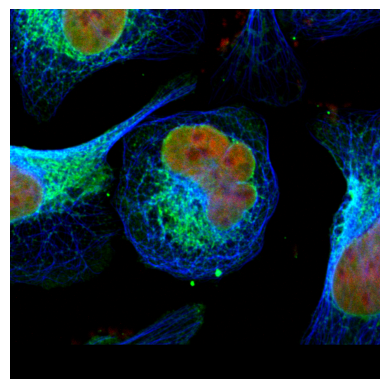

In [22]:
image = dataset[5] # 4, 1024, 1024

channels = [channel.unsqueeze(0) for channel in image]
concatenated_image = torch.cat(channels[:-1], dim=0)
image_data_rgb = np.transpose(concatenated_image, (1, 2, 0))

image_data_rgb.shape
plt.imshow(image_data_rgb)
plt.axis('off')
plt.savefig(f'full_slide_hpa.png', bbox_inches='tight', pad_inches=0)

# for ch in range(concatenated_image.shape[0]):
#     channel = concatenated_image[ch, : , :]
#     plt.imshow(channel, cmap='grey')
#     plt.axis('off')
#     plt.savefig(f'ch_{ch}.png', bbox_inches='tight', pad_inches=0)

In [ ]:
plt.axis('off')